# Perbandingan Model BERT Multi-Label — Klasifikasi Emosi Tweet ID

Pipeline: load cleaned XLSX → preprocessing (clean→casefold→normalize+emoji) → auto-label via IndoNLU EmoT (top-k=2 multi-label) → split 80/10/10 → train 5 model (IndoBERT baseline + IndoBERTweet, IndoNLU, XLM-R, mBERT) → eval multi-label + 6 plot.

Run: Colab (T4 GPU) atau Jupyter lokal. Set `DATA_PATH` sesuai. Cell self-contained.


In [6]:
import os, random, numpy as np, torch, sys
from pathlib import Path
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}  torch: {torch.__version__}  py: {sys.version.split()[0]}')
PROJECT_DIR = Path.cwd()
RESULTS_DIR, MODEL_DIR = PROJECT_DIR / 'results', PROJECT_DIR / 'models'
for output_dir in (RESULTS_DIR, MODEL_DIR): output_dir.mkdir(parents=True, exist_ok=True)
DATA_PATH = Path(os.environ.get('SIPEMO_DATASET', PROJECT_DIR / 'data' / 'tugas-akhir_cleaned.xlsx'))
DATA_PATH_COLAB = None  # set ke '/content/tugas-akhir_cleaned.xlsx' kalau di Colab
LABEL_COLS = ['senang','sedih','marah','takut']
MAX_LEN, BATCH, EPOCHS, LR = 96, 16, 3, 2e-5


Device: cpu  torch: 2.13.0+cpu  py: 3.10.0


In [7]:
%pip install -q transformers==4.44.0 datasets==2.21.0 accelerate torch scikit-learn pandas openpyxl matplotlib


Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\ASUS\AppData\Local\Progr

In [9]:
import pandas as pd, re
SLANG = {'gk':'tidak','ga':'tidak','gak':'tidak','nggak':'tidak','kagak':'tidak','tdk':'tidak',
 'bgt':'banget','emg':'memang','emang':'memang','udh':'sudah','udah':'sudah','skrg':'sekarang',
 'trs':'terus','dr':'dari','klo':'kalau','kalo':'kalau','kl':'kalau','jg':'juga','aja':'saja',
 'doang':'saja','sm':'sama','sy':'saya','aq':'aku','gw':'saya','gue':'saya','lu':'kamu',
 'loe':'kamu','kmu':'kamu','km':'kamu','org':'orang','temen':'teman','tmn':'teman',
 'dmn':'dimana','gimana':'bagaimana','gmn':'bagaimana','krn':'karena','karna':'karena',
 'bbrp':'beberapa','byk':'banyak','dikit':'sedikit','dkt':'sedikit'}
EMOJI_RX = re.compile(r'[\U0001F300-\U0001FAFF\U0001F600-\U0001F64F\U0001F900-\U0001F9FF❤️]')
URL_RX   = re.compile(r'https?://\S+|www\.\S+'); MENT_RX = re.compile(r'@\w+')
HASH_RX  = re.compile(r'#(\w+)'); WS_RX = re.compile(r'\s+'); REPEAT_RX = re.compile(r'(.)\1{2,}')

def _norm(text):
    t = URL_RX.sub(' ', text); t = MENT_RX.sub(' ', t); t = HASH_RX.sub(r' \1 ', t)
    t = t.lower(); t = REPEAT_RX.sub(r'\1\1', t)
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    return WS_RX.sub(' ', t).strip()

df = pd.read_excel(DATA_PATH_COLAB or DATA_PATH)[['full_text']].dropna().drop_duplicates().reset_index(drop=True)
df['full_text'] = df['full_text'].astype(str).str.slice(0, 300)
df = df[df['full_text'].str.strip().astype(bool)].reset_index(drop=True)
df['text_norm']   = df['full_text'].apply(lambda s: ' '.join(SLANG.get(w,w) for w in _norm(s).split()))
df['emoji_count'] = df['full_text'].apply(lambda s: len(EMOJI_RX.findall(s)))
df = df[df['text_norm'].str.strip().astype(bool)].reset_index(drop=True)
print('rows after prep:', len(df), '| emoji rate:', f"{df['emoji_count'].gt(0).mean()*100:.1f}%")

# ponyscope: IndoNLU EmoT if HF loads, else per-row lexicon fallback
_LEX = {
 'senang':{'senang','bahagia','gembira','suka','rindu','syukur','alhamdulillah','semangat','antusias','bangga','puas','lega','hebat','keren','mantap','good','love','happy','grateful','amazing','nice','seneng','😊','😄','😍','🥰','❤️','💕','👍','🎉'},
 'sedih' :{'sedih','pilu','nelangsa','muram','galau','hampa','kecewa','menyesal','kehilangan','menangis','😭','😢','😔','😞','💔'},
 'marah' :{'marah','kesal','jengkel','sebel','benci','muak','geram','emosi','dongkol','menyebalkan','sialan','bangsat','anjir','bodoamat','😡','😠','🤬'},
 'takut' :{'takut','cemas','khawatir','gelisah','panik','ngeri','horor','paranoid','worried','anxious','afraid','scared','😱','😨','😰'},
}
def _lex_one(text):
    ws = set(re.findall(r'[\w]+', text.lower())) | set(EMOJI_RX.findall(text))
    return [int(any(k in ws for k in _LEX[c])) for c in LABEL_COLS]

# Try IndoNLU EmoT auto-label
_pipe = None
try:
    from transformers import pipeline as _pl
    _pipe = _pl('text-classification', model='StevenLimcorn/indonesian-roberta-base-emotion-classifier',
                device=0 if DEVICE=='cuda' else -1, truncation=True, max_length=MAX_LEN)
except Exception as e:
    print('HF model load skipped:', type(e).__name__, str(e)[:80])

_HF_MAP = {'Senang':0,'Sedih':1,'Marah':2,'Takut':3}
def _hf_one(text):
    o = _pipe(text)
    o = o if isinstance(o, list) else [o]
    s = sorted(o, key=lambda x: -x['score'])[:2]
    bins = [0]*4
    for r in s:
        i = _HF_MAP.get(r['label'])
        if i is not None and r['score'] >= 0.30: bins[i] = 1
    return bins

def _label_row(text):
    if _pipe is not None:
        try:
            b = _hf_one(text)
            if sum(b) > 0: return b
        except Exception:
            pass
    return _lex_one(text)

import time; t0 = time.time()
df['labels'] = [_label_row(t) for t in df['text_norm']]
df = df[df['labels'].apply(sum) >= 1].reset_index(drop=True)
mode = 'HF top-k=2' if _pipe else 'lexicon-only'
print(f'mode={mode} | rows={len(df)} ({time.time()-t0:.1f}s)')
for i,c in enumerate(LABEL_COLS):
    print(f'  {c}: {sum(r[i] for r in df.labels)}/{len(df)}')

out = RESULTS_DIR / 'labeled_silver.xlsx'
df[['text_norm','emoji_count','labels']].to_excel(out, index=False)
print('saved labeled corpus:', out, 'rows:', len(df))


rows after prep: 19491 | emoji rate: 26.3%


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


mode=HF top-k=2 | rows=2188 (3245.6s)
  senang: 1492/2188
  sedih: 297/2188
  marah: 170/2188
  takut: 333/2188
saved labeled corpus: C:\\MULTI LABEL\\Hasil\\labeled_silver.xlsx rows: 2188


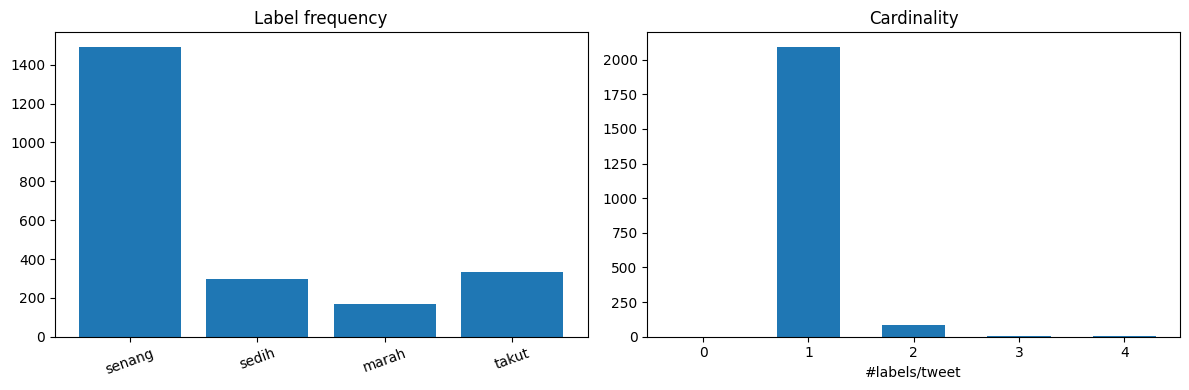

saved eda_labels.png
cardinality mean: 1.0475319926873858 max: 4
avg label/tweet: 1.05
top combo: [((np.int32(1), np.int32(0), np.int32(0), np.int32(0)), 1429), ((np.int32(0), np.int32(0), np.int32(0), np.int32(1)), 297), ((np.int32(0), np.int32(1), np.int32(0), np.int32(0)), 238), ((np.int32(0), np.int32(0), np.int32(1), np.int32(0)), 129), ((np.int32(1), np.int32(1), np.int32(0), np.int32(0)), 30)]
text len p50/p95: 25 46


In [10]:
import matplotlib.pyplot as plt, numpy as np
from collections import Counter
y_preview = np.array(df['labels'].tolist(), dtype=np.int32)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(LABEL_COLS, y_preview.sum(0))
axes[0].set_title('Label frequency'); axes[0].tick_params(axis='x', rotation=20)
npos = y_preview.sum(1)
axes[1].hist(npos, bins=[0,1,2,3,4,5], align='left', rwidth=0.6)
axes[1].set_xticks([0,1,2,3,4]); axes[1].set_xlabel('#labels/tweet'); axes[1].set_title('Cardinality')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_labels.png', dpi=120); plt.show()
print('saved eda_labels.png')
print('cardinality mean:', npos.mean(), 'max:', npos.max())
print('avg label/tweet:', f'{y_preview.sum()/len(y_preview):.2f}')
print('top combo:', Counter(map(tuple, y_preview)).most_common(5))
lens = df['text_norm'].str.split().str.len()
print('text len p50/p95:', int(lens.quantile(0.5)), int(lens.quantile(0.95)))


In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
y = np.array(df['labels'].tolist(), dtype=np.float32)
N = len(df)
idx_all = np.arange(N)
# ponytail: post-filter semua rows punya ≥1 label, stratify single-class — drop it
idx_train, idx_tmp = train_test_split(idx_all, test_size=0.2, random_state=SEED)
idx_val,   idx_test = train_test_split(idx_tmp, test_size=0.5, random_state=SEED)
print({'train': len(idx_train), 'val': len(idx_val), 'test': len(idx_test), 'total': N})


{'train': 1750, 'val': 219, 'test': 219, 'total': 2188}


In [12]:
MODELS = {
 'IndoBERT-base (baseline)': 'indobenchmark/indobert-base-p1',
 'IndoBERTweet'             : 'indolem/indobertweet-base-uncased',
 'IndoBERT-IndoNLU'         : 'indobenchmark/indobert-base-p2',
 'IndoBERT-IndoLEM'         : 'indolem/indobert-base-uncased',
 'XLM-RoBERTa-base'         : 'xlm-roberta-base',
 'mBERT-base'               : 'bert-base-multilingual-cased',
}
print('models:', list(MODELS.keys()))


models: ['IndoBERT-base (baseline)', 'IndoBERTweet', 'IndoBERT-IndoNLU', 'IndoBERT-IndoLEM', 'XLM-RoBERTa-base', 'mBERT-base']


In [13]:
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, hamming_loss, accuracy_score

class TxtDS(Dataset):
    def __init__(self, texts, labels, tok, max_len):
        self.texts, self.labels, self.tok, self.max_len = texts, labels, tok, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(self.texts[i], truncation=True, max_length=self.max_len, padding='max_length', return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'labels': torch.tensor(self.labels[i], dtype=torch.float)}


In [14]:
def best_thresh(logits, y_true):
    best_t, best_f = 0.5, -1
    for t in np.arange(0.20, 0.55, 0.05):
        f = f1_score(y_true, (logits >= t).astype(int), average='macro', zero_division=0)
        if f > best_f: best_f, best_t = f, t
    return best_t, best_f

def evaluate(model, loader):
    model.eval(); out_l, out_y = [], []
    with torch.no_grad():
        for b in loader:
            ids = b['input_ids'].to(DEVICE); mk = b['attention_mask'].to(DEVICE)
            out_l.append(torch.sigmoid(model(input_ids=ids, attention_mask=mk).logits).cpu().numpy())
            out_y.append(b['labels'].cpu().numpy())
    return np.concatenate(out_l), np.concatenate(out_y)


In [15]:
CHECKPOINT_FILES = {
    'IndoBERT-base (baseline)': MODEL_DIR / 'best_indobert_base.pt',
    'IndoBERTweet': MODEL_DIR / 'best_indobertweet.pt',
    'IndoBERT-IndoNLU': MODEL_DIR / 'best_indobert_indonlu.pt',
    'IndoBERT-IndoLEM': MODEL_DIR / 'best_indobert_indolem.pt',
    'XLM-RoBERTa-base': MODEL_DIR / 'best_xlm_roberta_base.pt',
    'mBERT-base': MODEL_DIR / 'best_mbert_base.pt',
}

histories, results = [], []
def train_one(name, model_path):
    checkpoint_path = CHECKPOINT_FILES[name]
    tok = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=4,
        problem_type='multi_label_classification').to(DEVICE)
    tr = DataLoader(TxtDS(df['text_norm'].values[idx_train].tolist(), y[idx_train].tolist(), tok, MAX_LEN),
                    batch_size=BATCH, shuffle=True)
    va = DataLoader(TxtDS(df['text_norm'].values[idx_val].tolist(), y[idx_val].tolist(), tok, MAX_LEN),
                    batch_size=BATCH*2)
    te = DataLoader(TxtDS(df['text_norm'].values[idx_test].tolist(), y[idx_test].tolist(), tok, MAX_LEN),
                    batch_size=BATCH*2)
    opt = torch.optim.AdamW(model.parameters(), lr=LR)
    sch = get_linear_schedule_with_warmup(opt, 0, len(tr)*EPOCHS)
    best_t, best_v = 0.5, -1
    h = {'name': name, 'loss': [], 'val_f1': []}
    for ep in range(EPOCHS):
        model.train(); losses = []
        for b in tr:
            ids, mk, lb = b['input_ids'].to(DEVICE), b['attention_mask'].to(DEVICE), b['labels'].to(DEVICE)
            out = model(input_ids=ids, attention_mask=mk, labels=lb)
            out.loss.backward(); opt.step(); sch.step(); opt.zero_grad()
            losses.append(out.loss.item())
        vl, vy = evaluate(model, va); t, f = best_thresh(vl, vy)
        h['loss'].append(float(np.mean(losses))); h['val_f1'].append(float(f))
        print(f'  [{name}] ep={ep+1} loss={np.mean(losses):.4f} val_F1macro={f:.4f} thr={t:.2f}')
        if f > best_v:
            best_v, best_t = f, t
            torch.save({'state_dict': model.state_dict(), 'thr': best_t, 'f1_macro': f}, checkpoint_path)
    best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(best_checkpoint['state_dict'], strict=True)
    tl, ty = evaluate(model, te); yp = (tl >= best_t).astype(int)
    r = {'model': name, 'threshold': float(best_t),
         'F1_micro': f1_score(ty,yp,average='micro',zero_division=0),
         'F1_macro': f1_score(ty,yp,average='macro',zero_division=0),
         'F1_samples': f1_score(ty,yp,average='samples',zero_division=0),
         'Hamming': hamming_loss(ty,yp),
         'SubsetAcc': accuracy_score(ty,yp),
         'per_label_F1': f1_score(ty,yp,average=None,zero_division=0).tolist(),
         'y_true_test': ty.tolist(), 'y_pred_test': yp.tolist()}
    histories.append(h); results.append(r)
    print(r)
    del model; torch.cuda.empty_cache()
    return r

for name, path in MODELS.items():
    print(f'\n=== {name} ({path}) ===')
    try:
        train_one(name, path)
    except Exception as e:
        print(f'  SKIP {name}: {e}')
        results.append({'model': name, 'F1_micro': None, 'F1_macro': None})



=== IndoBERT-base (baseline) (indobenchmark/indobert-base-p1) ===


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--indobenchmark--indobert-base-p1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\

  [IndoBERT-base (baseline)] ep=1 loss=0.2955 val_F1macro=0.8687 thr=0.35
  [IndoBERT-base (baseline)] ep=2 loss=0.0779 val_F1macro=0.9620 thr=0.25
  [IndoBERT-base (baseline)] ep=3 loss=0.0448 val_F1macro=0.9789 thr=0.30
{'model': 'IndoBERT-base (baseline)', 'threshold': 0.3, 'F1_micro': 0.9933774834437086, 'F1_macro': 0.9944570625135194, 'F1_samples': 0.9954337899543378, 'Hamming': 0.003424657534246575, 'SubsetAcc': 0.9863013698630136, 'per_label_F1': [0.9927536231884058, 1.0, 1.0, 0.9850746268656716], 'y_true_test': [[1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 1.0, 0

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--indolem--indobertweet-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\transforme

  [IndoBERTweet] ep=1 loss=0.3906 val_F1macro=0.6434 thr=0.25
  [IndoBERTweet] ep=2 loss=0.2173 val_F1macro=0.8257 thr=0.35
  [IndoBERTweet] ep=3 loss=0.1230 val_F1macro=0.8658 thr=0.40
{'model': 'IndoBERTweet', 'threshold': 0.39999999999999997, 'F1_micro': 0.874439461883408, 'F1_macro': 0.7249086499086499, 'F1_samples': 0.867579908675799, 'Hamming': 0.0639269406392694, 'SubsetAcc': 0.8310502283105022, 'per_label_F1': [0.9370629370629371, 0.7837837837837838, 0.3, 0.8787878787878788], 'y_true_test': [[1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [1.0, 0.0, 

...

  [IndoBERT-IndoLEM] ep=1 loss=0.4201 val_F1macro=0.4331 thr=0.25
  [IndoBERT-IndoLEM] ep=2 loss=0.2978 val_F1macro=0.7296 thr=0.40
  [IndoBERT-IndoLEM] ep=3 loss=0.1715 val_F1macro=0.7582 thr=0.25
{'model': 'IndoBERT-IndoLEM', 'threshold': 0.25, 'F1_micro': 0.8559837728194726, 'F1_macro': 0.7397899859790104, 'F1_samples': 0.882648401826484, 'Hamming': 0.08105022831050228, 'SubsetAcc': 0.771689497716895, 'per_label_F1': [0.9407665505226481, 0.7916666666666666, 0.3888888888888889, 0.8378378378378378], 'y_true_test': [[1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 1.0, 0.0, 

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--xlm-roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\tokenization_ut

  [XLM-RoBERTa-base] ep=1 loss=0.4360 val_F1macro=0.5520 thr=0.30
  [XLM-RoBERTa-base] ep=2 loss=0.2815 val_F1macro=0.6264 thr=0.25
  [XLM-RoBERTa-base] ep=3 loss=0.2063 val_F1macro=0.6746 thr=0.45
{'model': 'XLM-RoBERTa-base', 'threshold': 0.44999999999999996, 'F1_micro': 0.8746928746928747, 'F1_macro': 0.6416221828214925, 'F1_samples': 0.8051750380517503, 'Hamming': 0.05821917808219178, 'SubsetAcc': 0.7899543378995434, 'per_label_F1': [0.9548872180451128, 0.6885245901639344, 0.0, 0.9230769230769231], 'y_true_test': [[1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 1.0, 0.0

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--bert-base-multilingual-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\tok

  [mBERT-base] ep=1 loss=0.4096 val_F1macro=0.3773 thr=0.25
  [mBERT-base] ep=2 loss=0.2441 val_F1macro=0.7420 thr=0.20
  [mBERT-base] ep=3 loss=0.1607 val_F1macro=0.7816 thr=0.30
{'model': 'mBERT-base', 'threshold': 0.3, 'F1_micro': 0.8489795918367347, 'F1_macro': 0.7416654180401558, 'F1_samples': 0.8759512937595129, 'Hamming': 0.08447488584474885, 'SubsetAcc': 0.7442922374429224, 'per_label_F1': [0.9507042253521126, 0.7659574468085106, 0.375, 0.875], 'y_true_test': [[1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0],

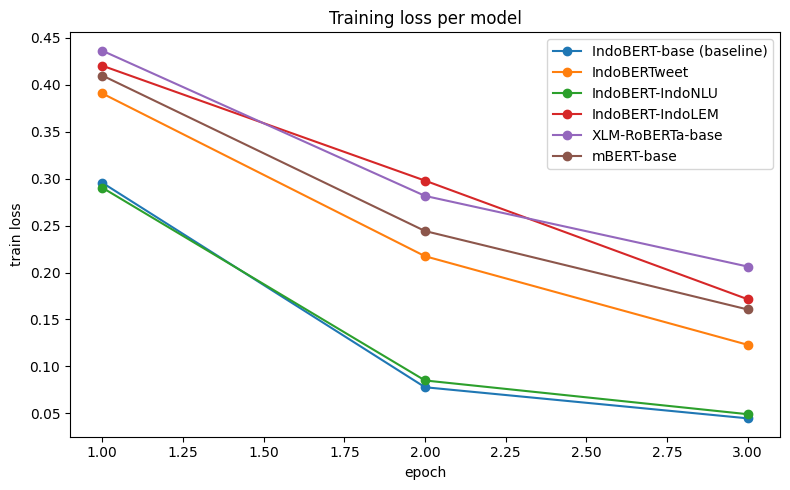

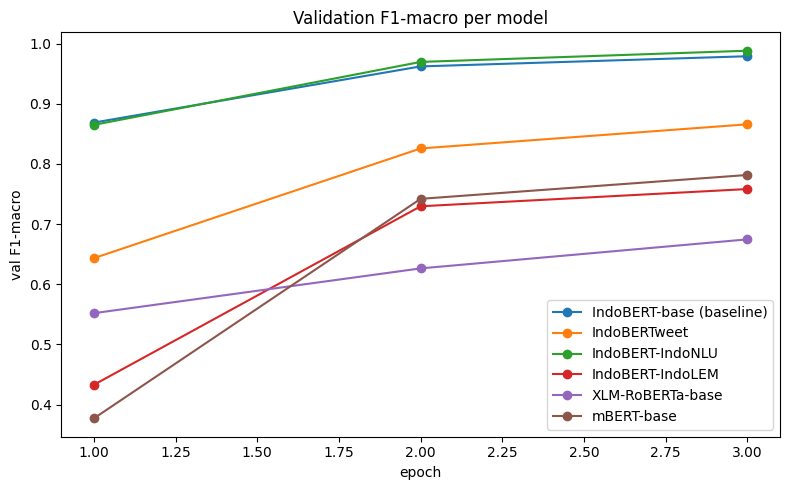

In [16]:
import matplotlib.pyplot as plt, numpy as np
# Plot 1: training loss per model
plt.figure(figsize=(8,5))
for h in histories:
    plt.plot(range(1, len(h['loss'])+1), h['loss'], marker='o', label=h['name'])
plt.xlabel('epoch'); plt.ylabel('train loss'); plt.title('Training loss per model')
plt.legend(); plt.tight_layout()
plt.savefig(RESULTS_DIR / 'plot_loss.png', dpi=120); plt.show()

# Plot 2: val F1-macro per model
plt.figure(figsize=(8,5))
for h in histories:
    plt.plot(range(1, len(h['val_f1'])+1), h['val_f1'], marker='o', label=h['name'])
plt.xlabel('epoch'); plt.ylabel('val F1-macro'); plt.title('Validation F1-macro per model')
plt.legend(); plt.tight_layout()
plt.savefig(RESULTS_DIR / 'plot_valF1.png', dpi=120); plt.show()


                   model  threshold  F1_micro  F1_macro  F1_samples  Hamming  SubsetAcc
IndoBERT-base (baseline)       0.30  0.993377  0.994457    0.995434 0.003425   0.986301
            IndoBERTweet       0.40  0.874439  0.724909    0.867580 0.063927   0.831050
        IndoBERT-IndoNLU       0.45  0.984410  0.977912    0.987823 0.007991   0.972603
        IndoBERT-IndoLEM       0.25  0.855984  0.739790    0.882648 0.081050   0.771689
        XLM-RoBERTa-base       0.45  0.874693  0.641622    0.805175 0.058219   0.789954
              mBERT-base       0.30  0.848980  0.741665    0.875951 0.084475   0.744292


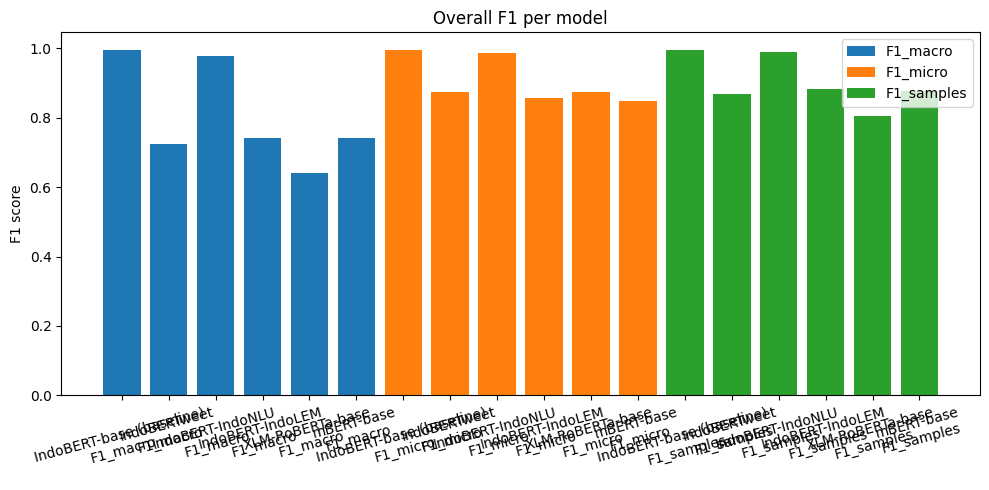

In [17]:
# Plot 3: overall F1 per model (micro/macro/sample)
rdf = pd.DataFrame([{k:v for k,v in r.items() if k not in ('per_label_F1','y_true_test','y_pred_test')} for r in results])
print(rdf.to_string(index=False))
melted = rdf.melt(id_vars='model', value_vars=['F1_micro','F1_macro','F1_samples'], var_name='metric', value_name='score')
plt.figure(figsize=(10,5))
for metric, g in melted.groupby('metric'):
    plt.bar([f'{m}\n{metric}' for m in g['model']], g['score'], label=metric)
plt.ylabel('F1 score'); plt.title('Overall F1 per model')
plt.xticks(rotation=15); plt.legend(); plt.tight_layout()
plt.savefig(RESULTS_DIR / 'plot_overall_f1.png', dpi=120); plt.show()


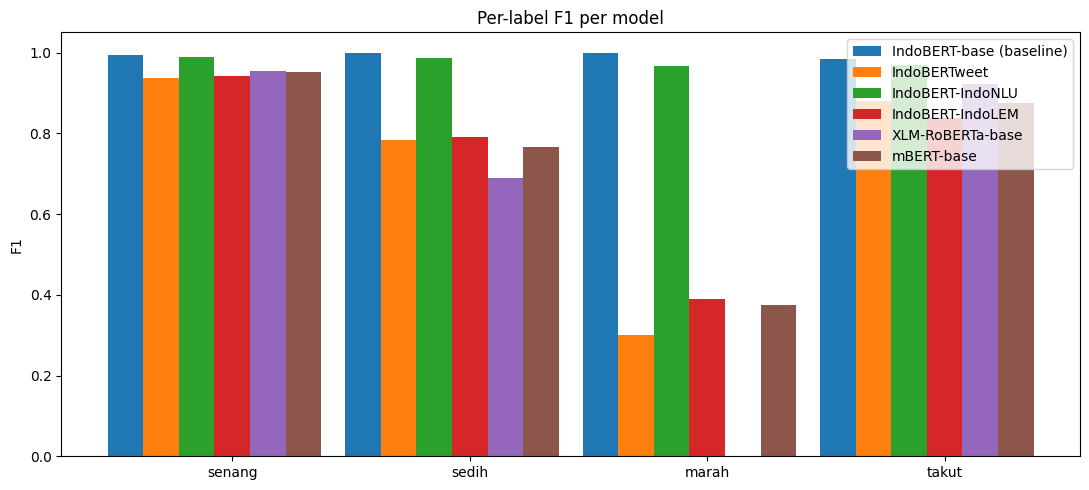

In [18]:
# Plot 4: per-label F1 grouped bar
fig, ax = plt.subplots(figsize=(11,5))
x = np.arange(len(LABEL_COLS)); width = 0.15
for i, r in enumerate(results):
    ax.bar(x + (i - len(results)/2)*width, r.get('per_label_F1',[0]*4), width, label=r['model'])
ax.set_xticks(x); ax.set_xticklabels(LABEL_COLS)
ax.set_ylabel('F1'); ax.set_title('Per-label F1 per model')
ax.legend(loc='upper right'); plt.tight_layout()
plt.savefig(RESULTS_DIR / 'plot_perlabel_f1.png', dpi=120); plt.show()


In [19]:
import os
try:
    import seaborn as sns
except ImportError:
    sns = None
from sklearn.metrics import confusion_matrix

saved = []
for r in [x for x in results if x.get('y_true_test')]:
    yt = np.array(r['y_true_test']); yp = np.array(r['y_pred_test'])
    fig, axes = plt.subplots(1, 4, figsize=(16,4))
    for i,c in enumerate(LABEL_COLS):
        cm = confusion_matrix(yt[:,i], yp[:,i])
        if sns is not None:
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                        xticklabels=['neg','pos'], yticklabels=['neg','pos'])
        else:
            axes[i].imshow(cm, cmap='Blues'); axes[i].set_xticks([0,1]); axes[i].set_yticks([0,1])
            for ri in range(2):
                for col in range(2):
                    axes[i].text(col, ri, str(cm[ri,col]), ha='center', va='center', color='red')
        axes[i].set_title(f'{r["model"]} - {c}')
    plt.tight_layout()
    safe = r['model'].replace(' ','_').replace('(','').replace(')','').lower()
    out = RESULTS_DIR / f'cm_{safe}.png'
    plt.savefig(out, dpi=120); plt.close(fig)
    saved.append(out)

for p in saved: print('saved', p, '->', os.path.exists(p))


saved C:\MULTI LABEL\Hasil\cm_indobert-base_baseline.png -> True
saved C:\MULTI LABEL\Hasil\cm_indobertweet.png -> True
saved C:\MULTI LABEL\Hasil\cm_indobert-indonlu.png -> True
saved C:\MULTI LABEL\Hasil\cm_indobert-indolem.png -> True
saved C:\MULTI LABEL\Hasil\cm_xlm-roberta-base.png -> True
saved C:\MULTI LABEL\Hasil\cm_mbert-base.png -> True


In [20]:
import pandas as pd
import numpy as np

# === Save summary ke Excel ===
out_rows = []
for r in results:
    row = {k:v for k,v in r.items() if k not in ('per_label_F1','y_true_test','y_pred_test')}
    if r.get('per_label_F1'):
        for i,c in enumerate(LABEL_COLS): row[f'F1_{c}'] = r['per_label_F1'][i]
    out_rows.append(row)
out = RESULTS_DIR / 'hasil_multilabel.xlsx'
pd.DataFrame(out_rows).to_excel(out, index=False)
print('saved summary:', out)

# === Inference: pakai model terbaik (F1-macro tertinggi) reuses predictions di test set ===
best = max([r for r in results if r.get('F1_micro')], key=lambda r: r['F1_macro'])
print(f"best model by F1-macro: {best['model']} (F1_macro={best['F1_macro']:.3f}, thr={best['threshold']:.2f})")

# Reuse y_pred_test langsung (no retrain, no weight reload — model objects were freed)
demo = pd.DataFrame({
    'text': df['text_norm'].values[idx_test].tolist(),
    'true_senang': y[idx_test,0], 'true_sedih': y[idx_test,1], 'true_marah': y[idx_test,2], 'true_takut': y[idx_test,3],
    'pred_senang': list(np.asarray(best['y_pred_test'])[:,0]),
    'pred_sedih': list(np.asarray(best['y_pred_test'])[:,1]),
    'pred_marah': list(np.asarray(best['y_pred_test'])[:,2]),
    'pred_takut': list(np.asarray(best['y_pred_test'])[:,3]),
})
out2 = RESULTS_DIR / 'inference_demo_best_model.xlsx'
demo.to_excel(out2, index=False)
print('saved inference demo:', out2, 'rows:', len(demo))


saved summary: C:\\MULTI LABEL\\Hasil\hasil_multilabel.xlsx
best model by F1-macro: IndoBERT-base (baseline) (F1_macro=0.994, thr=0.30)
saved inference demo: C:\\MULTI LABEL\\Hasil\inference_demo_best_model.xlsx rows: 219


In [35]:
# === Sistem Prediksi Multi-Label Emosi (Prototype CLI) ===
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import logging as hf_logging
import warnings; warnings.filterwarnings('ignore')

hf_logging.set_verbosity_error()
MODELS = {
    'IndoBERT-base (baseline)': 'indobenchmark/indobert-base-p1',
    'IndoBERTweet': 'indolem/indobertweet-base-uncased',
    'IndoBERT-IndoNLU': 'indobenchmark/indobert-base-p2',
    'IndoBERT-IndoLEM': 'indolem/indobert-base-uncased',
    'XLM-RoBERTa-base': 'xlm-roberta-base',
    'mBERT-base': 'bert-base-multilingual-cased',
}

# Gunakan checkpoint tersendiri milik model terbaik.
best = max([r for r in results if r.get('F1_micro')], key=lambda r: r['F1_macro'])
best_path = MODELS[best['model']]
ckpt = CHECKPOINT_FILES[best['model']]

if not ckpt.exists():
    raise FileNotFoundError(
        f'Checkpoint model terbaik belum tersedia: {ckpt}. Jalankan training terlebih dahulu.'
    )

sd = torch.load(ckpt, map_location=DEVICE, weights_only=True)
state_dict = sd['state_dict']
if any(k.startswith('module.') for k in state_dict):
    state_dict = {k.replace('module.', '', 1): v for k, v in state_dict.items()}

tok_i = AutoTokenizer.from_pretrained(best_path)
mdl_i = AutoModelForSequenceClassification.from_pretrained(
    best_path, num_labels=len(LABEL_COLS), problem_type='multi_label_classification'
).to(DEVICE)
mdl_i.load_state_dict(state_dict, strict=True)
best_thr = float(sd.get('thr', best['threshold']))
mdl_i.eval()

def _norm(text):
    t = URL_RX.sub(' ', text); t = MENT_RX.sub(' ', t); t = HASH_RX.sub(r' \1 ', t)
    t = t.lower(); t = REPEAT_RX.sub(r'\1\1', t)
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    return WS_RX.sub(' ', t).strip()

def _label_emoji_set(em):
    found = [0]*len(LABEL_COLS)
    for e in em:
        for i,c in enumerate(LABEL_COLS):
            if e in _LEX.get(c, set()): found[i] = 1
    return found

def predict_one(raw):
    norm = ' '.join(SLANG.get(w, w) for w in _norm(raw).split())
    emojis = EMOJI_RX.findall(raw)
    enc = tok_i(norm, truncation=True, max_length=MAX_LEN, padding=True, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        prob = 1/(1+np.exp(-mdl_i(**enc).logits.cpu().numpy()[0]))
    bin_bert = (prob >= best_thr).astype(int)
    bin_emoji = np.array(_label_emoji_set(emojis))
    bin_fused = (bin_bert | bin_emoji).astype(int)
    return {'text': raw, 'norm': norm, 'emojis_found': emojis,
            **{f'prob_{c}': float(prob[i]) for i,c in enumerate(LABEL_COLS)},
            **{f'pred_bert_{c}': int(bin_bert[i]) for i,c in enumerate(LABEL_COLS)},
            **{f'pred_emoji_{c}': int(bin_emoji[i]) for i,c in enumerate(LABEL_COLS)},
            **{f'pred_fused_{c}': int(bin_fused[i]) for i,c in enumerate(LABEL_COLS)}}

def render(r):
    emo = '/'.join(r['emojis_found']) if r['emojis_found'] else '(none)'
    tbl = pd.DataFrame({
        'label': LABEL_COLS,
        'prob': [round(r[f'prob_{c}'], 3) for c in LABEL_COLS],
        'bert': [r[f'pred_bert_{c}'] for c in LABEL_COLS],
        'emoji': [r[f'pred_emoji_{c}'] for c in LABEL_COLS],
        'fused': [r[f'pred_fused_{c}'] for c in LABEL_COLS],
    })
    txt_fused = ', '.join(c for c in LABEL_COLS if r[f'pred_fused_{c}']) or '(none)'
    txt_bert = ', '.join(c for c in LABEL_COLS if r[f'pred_bert_{c}']) or '(none)'
    print('\n' + '-'*60)
    print(f'Input   : {r["text"]}')
    print(f'Normal  : {r["norm"]}')
    print(f'Emoji   : {emo}')
    print(tbl.to_string(index=False))
    print(f'BERT    : {txt_bert}')
    print(f'Fused   : {txt_fused}')

print('='*60)
print(f' SISTEM PREDIKSI EMOSI MULTI-LABEL')
print(f' Model  : {best["model"]}')
print(f' F1 μ   : {best["F1_micro"]:.3f}')
print(f' F1 M   : {best["F1_macro"]:.3f}')
print(f' Thresh : {best_thr:.3f}')
print(f' Labels : {", ".join(LABEL_COLS)}')
print('='*60)
print('Ketik tweet, enter kosong = selesai (maks 20 input):\n')

history = []
for i in range(20):
    try:
        s = input(f'[{i+1:02d}] > ').strip()
    except (EOFError, KeyboardInterrupt):
        print('\n(interrupt)'); break
    if not s:
        break
    r = predict_one(s)
    render(r)
    history.append(r)

if history:
    hdf = pd.DataFrame(history)
    for c in LABEL_COLS:
        hdf[f'pred_{c}'] = hdf[f'pred_fused_{c}']
        hdf.drop(columns=[f'pred_fused_{c}'], inplace=True)
    out = RESULTS_DIR / 'inference_session_log.xlsx'
    hdf.to_excel(out, index=False)
    print(f'\n[log] saved {len(history)} prediksi ke {out}')

print('\nRingkasan sesi:')
print(f'  total input         : {len(history)}')
print(f'  multi-label terdeteksi : {sum(any(history[i][f"pred_fused_{c}"] for c in LABEL_COLS) for i in range(len(history)))}')
print(f'  distribusi label    :')
for c in LABEL_COLS:
    pos = sum(r[f'pred_fused_{c}'] for r in history)
    print(f'    {c:<6}: {pos:>3}  ({100*pos/max(1,len(history)):.1f}%)')

print('\nsesi selesai.')


 SISTEM PREDIKSI EMOSI MULTI-LABEL
 Model  : IndoBERT-base (baseline)
 F1 μ   : 0.993
 F1 M   : 0.994
 Thresh : 0.300
 Labels : senang, sedih, marah, takut
Ketik tweet, enter kosong = selesai (maks 20 input):


------------------------------------------------------------
Input   : Wah, ternyata hasilnya jauh lebih bagus dari yang saya kira.😲✨ :)
Normal  : wah ternyata hasilnya jauh lebih bagus dari yang saya kira
Emoji   : 😲
 label  prob  bert  emoji  fused
senang 0.424     1      0      1
 sedih 0.536     1      0      1
 marah 0.195     0      0      0
 takut 0.039     0      0      0
BERT    : senang, sedih
Fused   : senang, sedih

[log] saved 1 prediksi ke C:\\MULTI LABEL\\Hasil\\inference_session_log.xlsx

Ringkasan sesi:
  total input         : 1
  multi-label terdeteksi : 1
  distribusi label    :
    senang:   1  (100.0%)
    sedih :   1  (100.0%)
    marah :   0  (0.0%)
    takut :   0  (0.0%)

sesi selesai.
